# Etapa 2 - Análise Exploratória de Dados

## Mobilidade Urbana Inteligente

Utilizamos diretamente o arquivo `ubernymaio14_tratado.csv`, produzido 
pelo notebook da Etapa 1, e concentra toda a
Análise Exploratória de Dados (EDA) solicitada:

- estatísticas descritivas, histogramas e boxplots;
- correlações de Pearson e Spearman;
- identificação de variáveis altamente correlacionadas;
- seleção preliminar de atributos e PCA;
- visualização bidimensional;
- análise do impacto das representações na proximidade.

> **Observação:** no arquivo tratado, `Lat`, `Lon` e `Hour` já estão normalizados pela
> Etapa 1. Portanto, as análises abaixo avaliam exatamente os dados que serão usados
> nas próximas etapas do projeto.


## 1. Bibliotecas e configurações

O notebook usa NumPy, SciPy e Matplotlib. As funções auxiliares abaixo servem apenas
para apresentar tabelas de forma legível e manter os cálculos reproduzíveis.


In [1]:
import csv
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-etapa2")

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial import cKDTree
from scipy.spatial.distance import pdist
from scipy.stats import skew, spearmanr

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

SEED = 42
COLUNAS_NUMERICAS = ["Lat", "Lon", "Hour", "Day"]

def imprimir_tabela(cabecalho, linhas, casas=4):
    # Imprime uma tabela simples sem depender de bibliotecas adicionais.
    formatadas = []
    for linha in linhas:
        formatada = []
        for valor in linha:
            if isinstance(valor, (float, np.floating)):
                formatada.append(f"{valor:.{casas}f}")
            else:
                formatada.append(str(valor))
        formatadas.append(formatada)
    larguras = [
        max(len(str(cabecalho[i])), *(len(linha[i]) for linha in formatadas))
        for i in range(len(cabecalho))
    ]
    print(" | ".join(str(v).ljust(larguras[i]) for i, v in enumerate(cabecalho)))
    print("-+-".join("-" * largura for largura in larguras))
    for linha in formatadas:
        print(" | ".join(valor.ljust(larguras[i]) for i, valor in enumerate(linha)))

print("Bibliotecas carregadas e semente definida:", SEED)


Bibliotecas carregadas e semente definida: 42


## 2. Carregamento dos dados tratados

O notebook procura o arquivo tratado tanto no diretório pai quanto no diretório atual.
Isso permite executá-lo abrindo o Jupyter pela pasta do projeto ou diretamente pela
pasta `etapa2`.


In [ ]:
CAMINHOS_POSSIVEIS = [
    Path("../ubernymaio14_tratado.csv"),
    Path("ubernymaio14_tratado.csv"),
]
CAMINHO_DADOS = next((p for p in CAMINHOS_POSSIVEIS if p.exists()), None)
if CAMINHO_DADOS is None:
    raise FileNotFoundError(
        "Execute primeiro a Etapa 1 para gerar 'ubernymaio14_tratado.csv'."
    )

with CAMINHO_DADOS.open(newline="", encoding="utf-8") as arquivo:
    registros = list(csv.DictReader(arquivo))

X = np.asarray(
    [[float(registro[coluna]) for coluna in COLUNAS_NUMERICAS] for registro in registros],
    dtype=float,
)
bases = np.asarray([registro["Base"] for registro in registros])
datas = np.asarray([registro["Date/Time"] for registro in registros])

print("Dimensão do conjunto:", X.shape)
print("Colunas disponíveis:", list(registros[0].keys()))
print("\nPrimeiros 5 registros:")
imprimir_tabela(
    ["Date/Time", "Lat", "Lon", "Base", "Hour", "Day"],
    [
        [
            r["Date/Time"],
            float(r["Lat"]),
            float(r["Lon"]),
            r["Base"],
            float(r["Hour"]),
            float(r["Day"]),
        ]
        for r in registros[:5]
    ],
)


## 3. Qualidade dos dados

Como a entrada já passou pelo pré-processamento da Etapa 1, espera-se que não existam
valores ausentes nem duplicatas. Esta verificação confirma a qualidade da entrada antes
da EDA.


In [3]:
ausentes = {
    coluna: sum(registro[coluna] == "" for registro in registros)
    for coluna in registros[0]
}
duplicatas = len(registros) - len({
    tuple(registro[coluna] for coluna in registros[0])
    for registro in registros
})

print("Quantidade de registros:", len(registros))
print("Duplicatas:", duplicatas)
print("\nValores ausentes por coluna:")
imprimir_tabela(["Coluna", "Ausentes"], list(ausentes.items()), casas=0)


Quantidade de registros: 19220
Duplicatas: 0

Valores ausentes por coluna:
Coluna    | Ausentes
----------+---------
Date/Time | 0       
Lat       | 0       
Lon       | 0       
Base      | 0       
Hour      | 0       
Day       | 0       


## 4. Estatísticas descritivas e outliers

As estatísticas resumem tendência central, dispersão e formato das distribuições.
Também contamos possíveis outliers pelo critério do intervalo interquartil
(`1,5 × IQR`). Essa contagem é exploratória: valores extremos espaciais podem representar
corridas reais e não devem ser removidos automaticamente.


In [4]:
estatisticas = []
for indice, coluna in enumerate(COLUNAS_NUMERICAS):
    valores = X[:, indice]
    q1, mediana, q3 = np.quantile(valores, [0.25, 0.50, 0.75])
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = np.sum((valores < limite_inferior) | (valores > limite_superior))
    estatisticas.append([
        coluna,
        len(valores),
        np.mean(valores),
        np.std(valores, ddof=1),
        np.min(valores),
        q1,
        mediana,
        q3,
        np.max(valores),
        skew(valores, bias=False),
        int(outliers),
    ])

imprimir_tabela(
    ["Variável", "N", "Média", "Desvio", "Mín.", "Q1", "Mediana", "Q3", "Máx.", "Assimetria", "Outliers IQR"],
    estatisticas,
)


Variável | N     | Média  | Desvio | Mín.   | Q1     | Mediana | Q3      | Máx.    | Assimetria | Outliers IQR
---------+-------+--------+--------+--------+--------+---------+---------+---------+------------+-------------
Lat      | 19220 | 0.4040 | 0.0447 | 0.0000 | 0.3816 | 0.4080  | 0.4264  | 1.0000  | 1.5017     | 855         
Lon      | 19220 | 0.2863 | 0.0263 | 0.0000 | 0.2780 | 0.2841  | 0.2899  | 1.0000  | 2.4602     | 1856        
Hour     | 19220 | 0.6231 | 0.2371 | 0.0000 | 0.4348 | 0.6522  | 0.7826  | 1.0000  | -0.5594    | 0           
Day      | 19220 | 8.4074 | 4.6664 | 1.0000 | 4.0000 | 8.0000  | 13.0000 | 16.0000 | 0.0364     | 0           


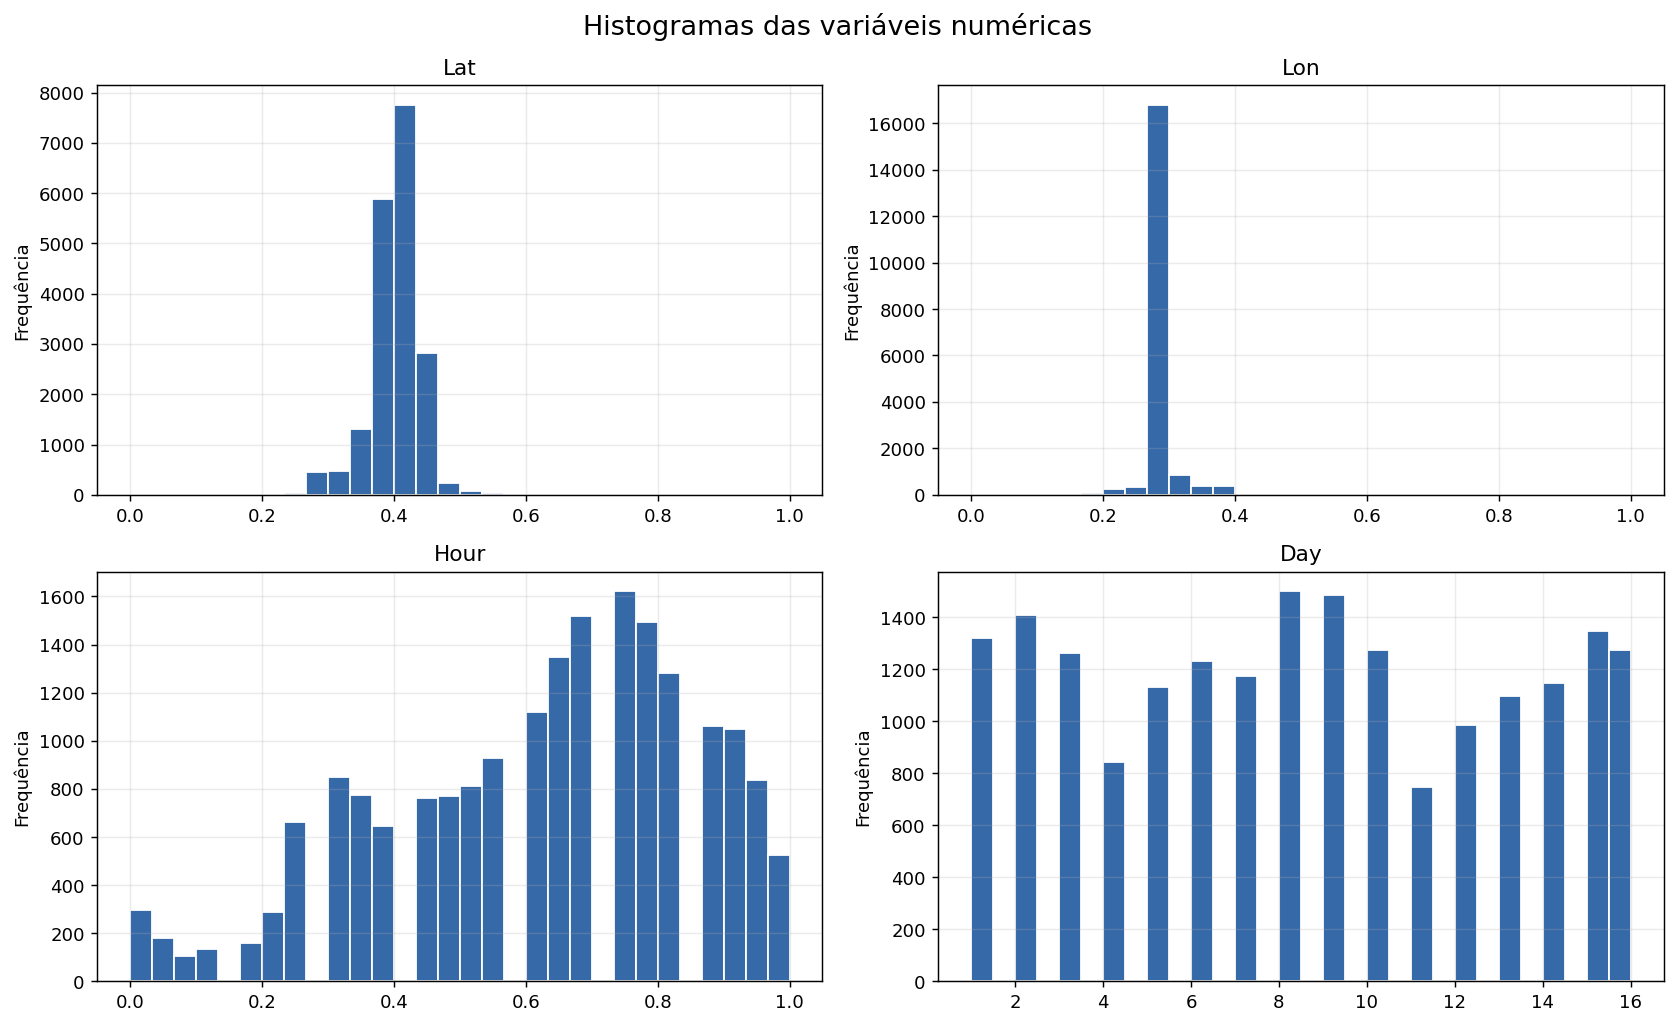

In [5]:
fig, eixos = plt.subplots(2, 2, figsize=(13, 8))
for indice, eixo in enumerate(eixos.flat):
    eixo.hist(X[:, indice], bins=30, color="#3569a8", edgecolor="white")
    eixo.set_title(COLUNAS_NUMERICAS[indice])
    eixo.set_ylabel("Frequência")
fig.suptitle("Histogramas das variáveis numéricas", fontsize=15)
fig.tight_layout()
plt.show()


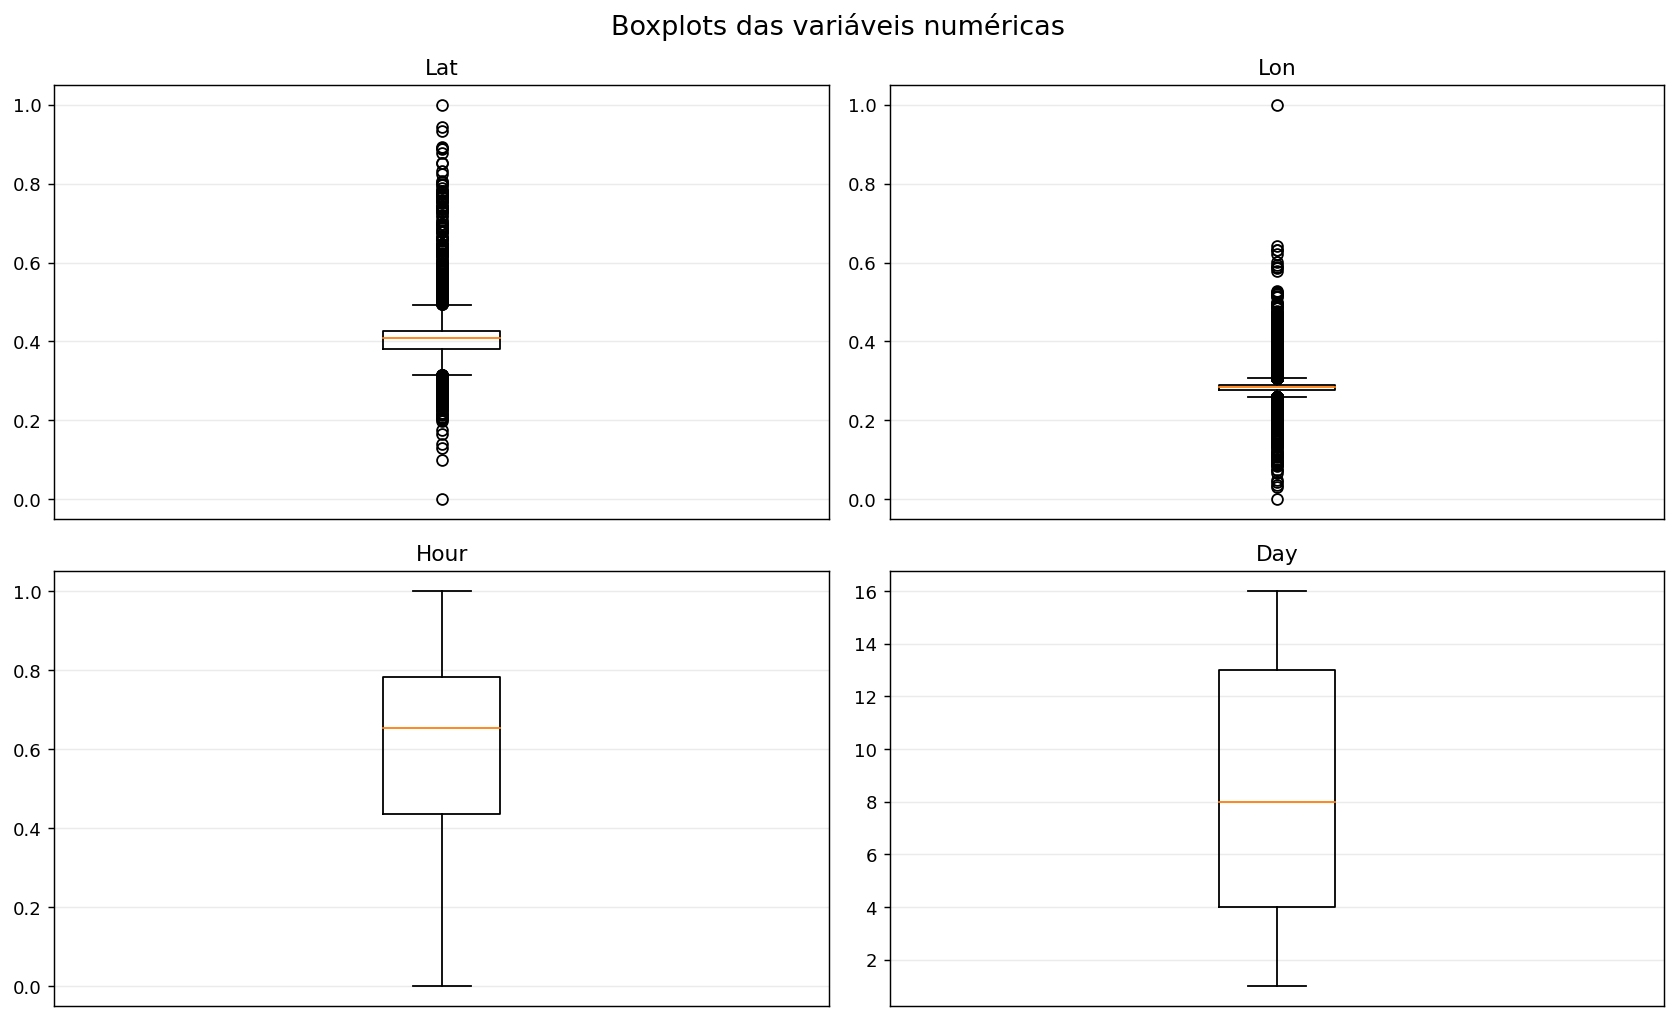

In [6]:
fig, eixos = plt.subplots(2, 2, figsize=(13, 8))
for indice, eixo in enumerate(eixos.flat):
    eixo.boxplot(X[:, indice], vert=True)
    eixo.set_title(COLUNAS_NUMERICAS[indice])
    eixo.set_xticks([])
fig.suptitle("Boxplots das variáveis numéricas", fontsize=15)
fig.tight_layout()
plt.show()


### Distribuição espacial e por base

O gráfico espacial mostra como os pontos tratados se distribuem no plano `Lon × Lat`.
A cor representa a hora normalizada. A contagem por base verifica a composição
categórica da amostra.


Distribuição por base:
Base   | Quantidade | Percentual
-------+------------+-----------
B02512 | 19220      | 100.0000  


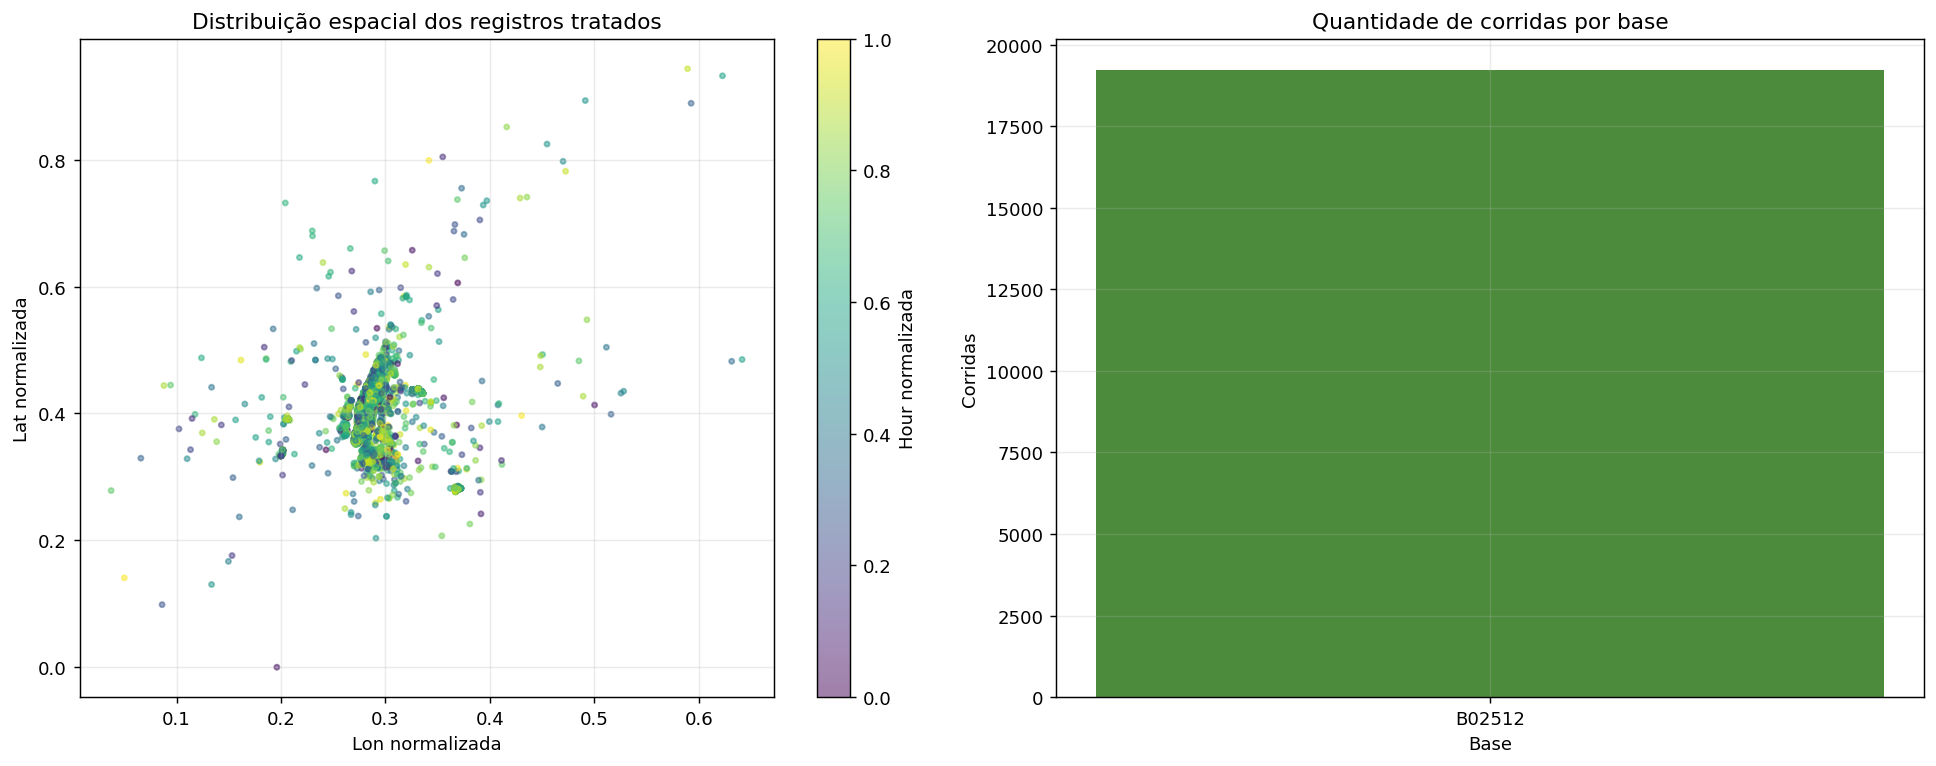

In [7]:
rng = np.random.default_rng(SEED)
amostra_espacial = rng.choice(len(X), size=min(8000, len(X)), replace=False)

fig, eixos = plt.subplots(1, 2, figsize=(15, 6))
pontos = eixos[0].scatter(
    X[amostra_espacial, 1],
    X[amostra_espacial, 0],
    c=X[amostra_espacial, 2],
    cmap="viridis",
    s=8,
    alpha=0.5,
)
eixos[0].set_title("Distribuição espacial dos registros tratados")
eixos[0].set_xlabel("Lon normalizada")
eixos[0].set_ylabel("Lat normalizada")
fig.colorbar(pontos, ax=eixos[0], label="Hour normalizada")

bases_unicas, contagens_base = np.unique(bases, return_counts=True)
eixos[1].bar(bases_unicas, contagens_base, color="#4b8b3b")
eixos[1].set_title("Quantidade de corridas por base")
eixos[1].set_xlabel("Base")
eixos[1].set_ylabel("Corridas")
fig.tight_layout()
plt.show()

print("Distribuição por base:")
imprimir_tabela(
    ["Base", "Quantidade", "Percentual"],
    [[base, int(qtd), qtd / len(bases) * 100] for base, qtd in zip(bases_unicas, contagens_base)],
)


## 5. Correlações de Pearson e Spearman

- **Pearson** mede relações lineares.
- **Spearman** mede relações monotônicas a partir dos postos.

Será adotado `|correlação| ≥ 0,80` como critério para sinalizar possível redundância.


Matriz de Pearson:
Variável | Lat     | Lon     | Hour    | Day    
---------+---------+---------+---------+--------
Lat      | 1.0000  | 0.1473  | -0.0443 | 0.0144 
Lon      | 0.1473  | 1.0000  | 0.0087  | -0.0021
Hour     | -0.0443 | 0.0087  | 1.0000  | -0.0284
Day      | 0.0144  | -0.0021 | -0.0284 | 1.0000 

Matriz de Spearman:
Variável | Lat     | Lon     | Hour    | Day    
---------+---------+---------+---------+--------
Lat      | 1.0000  | 0.4960  | -0.0789 | 0.0202 
Lon      | 0.4960  | 1.0000  | -0.0435 | 0.0115 
Hour     | -0.0789 | -0.0435 | 1.0000  | -0.0381
Day      | 0.0202  | 0.0115  | -0.0381 | 1.0000 


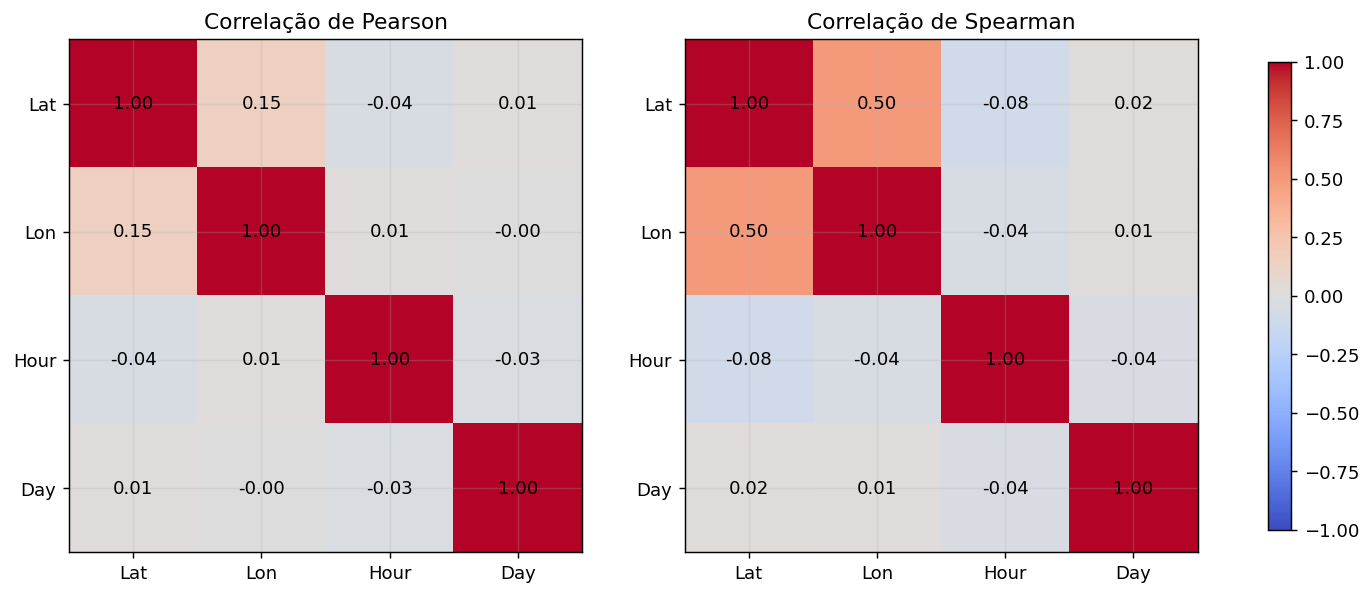

In [8]:
pearson = np.corrcoef(X, rowvar=False)
spearman = np.asarray(spearmanr(X, axis=0).statistic)

print("Matriz de Pearson:")
imprimir_tabela(["Variável", *COLUNAS_NUMERICAS], [
    [nome, *pearson[i]] for i, nome in enumerate(COLUNAS_NUMERICAS)
])
print("\nMatriz de Spearman:")
imprimir_tabela(["Variável", *COLUNAS_NUMERICAS], [
    [nome, *spearman[i]] for i, nome in enumerate(COLUNAS_NUMERICAS)
])

fig, eixos = plt.subplots(1, 2, figsize=(14, 5.5))
for eixo, matriz, titulo in zip(
    eixos,
    [pearson, spearman],
    ["Correlação de Pearson", "Correlação de Spearman"],
):
    imagem = eixo.imshow(matriz, vmin=-1, vmax=1, cmap="coolwarm")
    eixo.set_xticks(range(len(COLUNAS_NUMERICAS)), COLUNAS_NUMERICAS)
    eixo.set_yticks(range(len(COLUNAS_NUMERICAS)), COLUNAS_NUMERICAS)
    for i in range(len(COLUNAS_NUMERICAS)):
        for j in range(len(COLUNAS_NUMERICAS)):
            eixo.text(j, i, f"{matriz[i, j]:.2f}", ha="center", va="center")
    eixo.set_title(titulo)
fig.colorbar(imagem, ax=eixos, shrink=0.85)
plt.show()


## 6. Identificação de redundância e seleção preliminar

A seleção abaixo percorre as variáveis e remove uma coluna somente quando ela apresenta
correlação de Pearson absoluta maior ou igual a `0,80` com uma coluna já mantida.


In [9]:
LIMIAR_CORRELACAO = 0.80
pares_altos = []
for metodo, matriz in [("Pearson", pearson), ("Spearman", spearman)]:
    for i in range(len(COLUNAS_NUMERICAS)):
        for j in range(i + 1, len(COLUNAS_NUMERICAS)):
            if abs(matriz[i, j]) >= LIMIAR_CORRELACAO:
                pares_altos.append([
                    metodo,
                    COLUNAS_NUMERICAS[i],
                    COLUNAS_NUMERICAS[j],
                    matriz[i, j],
                ])

indices_mantidos = []
indices_removidos = []
for indice in range(len(COLUNAS_NUMERICAS)):
    if any(abs(pearson[indice, anterior]) >= LIMIAR_CORRELACAO for anterior in indices_mantidos):
        indices_removidos.append(indice)
    else:
        indices_mantidos.append(indice)

if pares_altos:
    print("Pares altamente correlacionados:")
    imprimir_tabela(["Método", "Variável 1", "Variável 2", "Correlação"], pares_altos)
else:
    print(f"Nenhum par apresentou |correlação| >= {LIMIAR_CORRELACAO:.2f}.")

print("\nVariáveis mantidas:", [COLUNAS_NUMERICAS[i] for i in indices_mantidos])
print("Variáveis removidas:", [COLUNAS_NUMERICAS[i] for i in indices_removidos])
print("\nConclusão: não há evidência de redundância suficiente para remover atributos.")


Nenhum par apresentou |correlação| >= 0.80.

Variáveis mantidas: ['Lat', 'Lon', 'Hour', 'Day']
Variáveis removidas: []

Conclusão: não há evidência de redundância suficiente para remover atributos.


## 7. PCA preliminar

Antes do PCA, as variáveis selecionadas são padronizadas para média zero e desvio
padrão um. Isso é necessário porque `Day` não foi normalizado na Etapa 1 e possui
escala diferente das demais colunas.

O PCA será avaliado pela variância explicada acumulada. O objetivo preliminar é
preservar pelo menos **90%** da variância.


In [10]:
X_selecionado = X[:, indices_mantidos]
medias = X_selecionado.mean(axis=0)
desvios = X_selecionado.std(axis=0, ddof=1)
Z = (X_selecionado - medias) / desvios

_, valores_singulares, componentes = np.linalg.svd(Z, full_matrices=False)
autovalores = valores_singulares ** 2 / (len(Z) - 1)
variancia_explicada = autovalores / autovalores.sum()
variancia_acumulada = np.cumsum(variancia_explicada)
scores_pca = Z @ componentes.T
n_componentes_90 = int(np.searchsorted(variancia_acumulada, 0.90) + 1)

print("Variância explicada:")
imprimir_tabela(
    ["Componente", "Individual (%)", "Acumulada (%)"],
    [
        [f"PC{i + 1}", variancia_explicada[i] * 100, variancia_acumulada[i] * 100]
        for i in range(len(variancia_explicada))
    ],
)
print(f"\nComponentes necessários para preservar ao menos 90%: {n_componentes_90}")

print("\nPesos dos componentes:")
imprimir_tabela(
    ["Componente", *[COLUNAS_NUMERICAS[i] for i in indices_mantidos]],
    [[f"PC{i + 1}", *componentes[i]] for i in range(len(componentes))],
)


Variância explicada:
Componente | Individual (%) | Acumulada (%)
-----------+----------------+--------------
PC1        | 28.8227        | 28.8227      
PC2        | 25.7571        | 54.5798      
PC3        | 24.3348        | 78.9146      
PC4        | 21.0854        | 100.0000     

Componentes necessários para preservar ao menos 90%: 4

Pesos dos componentes:
Componente | Lat     | Lon     | Hour    | Day    
-----------+---------+---------+---------+--------
PC1        | -0.7105 | -0.6729 | 0.1846  | -0.0917
PC2        | -0.0061 | -0.2746 | -0.6936 | 0.6659 
PC3        | 0.0525  | -0.1349 | -0.6572 | -0.7397
PC4        | -0.7017 | 0.6735  | -0.2300 | 0.0318 


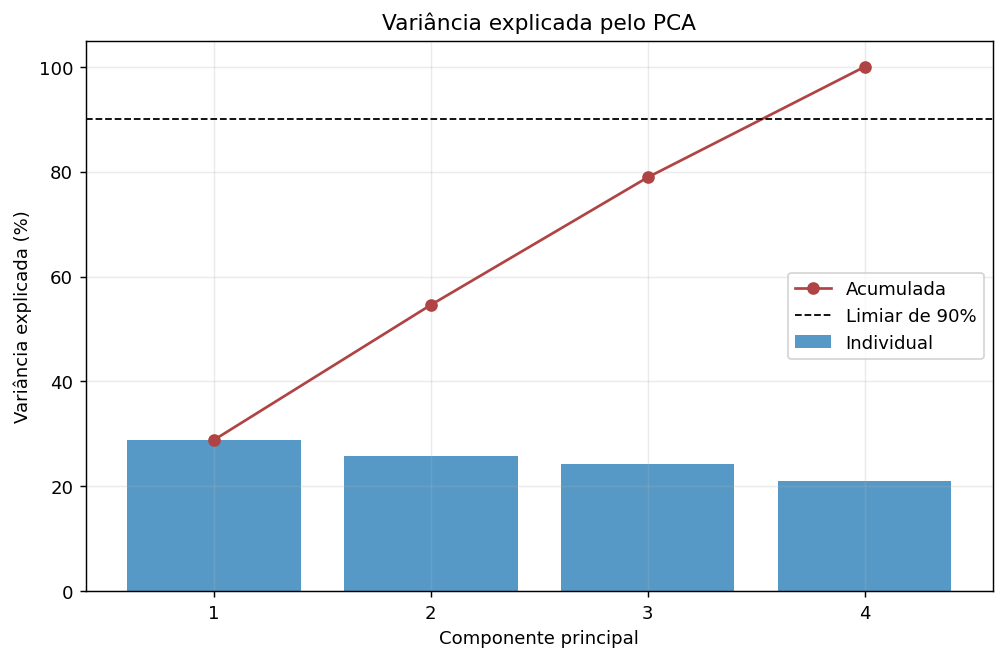

In [11]:
componentes_x = np.arange(1, len(variancia_explicada) + 1)
fig, eixo = plt.subplots(figsize=(9, 5.5))
eixo.bar(componentes_x, variancia_explicada * 100, alpha=0.75, label="Individual")
eixo.plot(componentes_x, variancia_acumulada * 100, marker="o", color="#b04444", label="Acumulada")
eixo.axhline(90, color="black", linestyle="--", linewidth=1, label="Limiar de 90%")
eixo.set_xticks(componentes_x)
eixo.set_xlabel("Componente principal")
eixo.set_ylabel("Variância explicada (%)")
eixo.set_title("Variância explicada pelo PCA")
eixo.legend()
plt.show()


### Visualização 2D com PCA

Mesmo quando duas componentes não preservam toda a variância, a projeção é útil para
explorar visualmente padrões e possíveis agrupamentos. A cor representa a hora
normalizada.


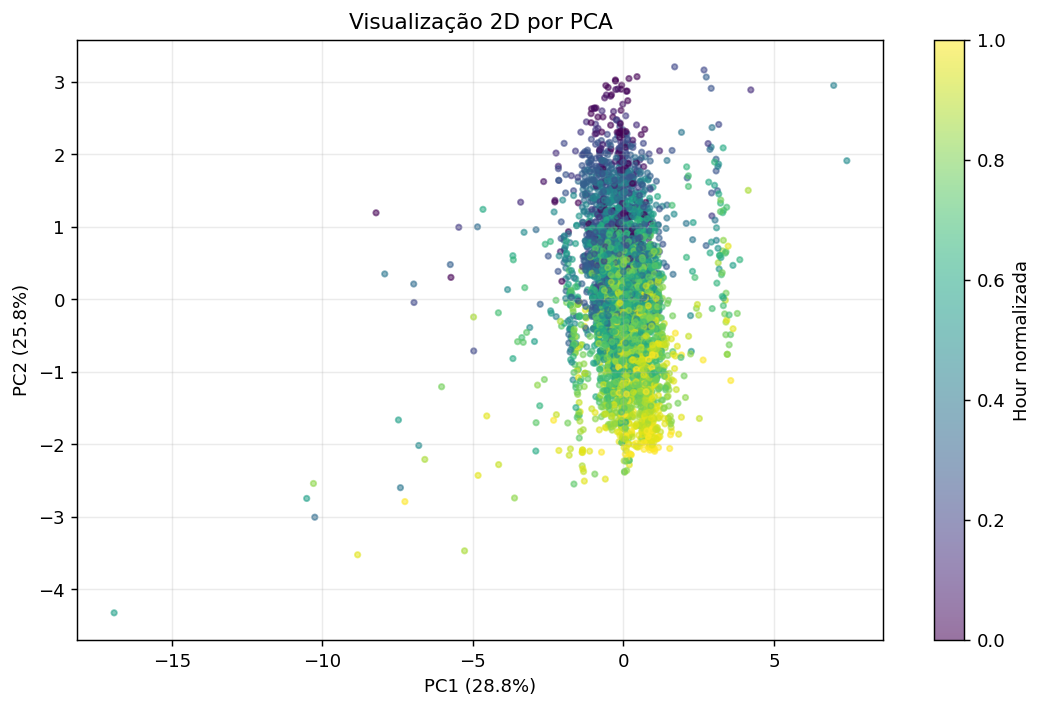

In [12]:
amostra_pca = rng.choice(len(scores_pca), size=min(5000, len(scores_pca)), replace=False)
fig, eixo = plt.subplots(figsize=(10, 6))
pontos = eixo.scatter(
    scores_pca[amostra_pca, 0],
    scores_pca[amostra_pca, 1],
    c=X[amostra_pca, 2],
    cmap="viridis",
    s=9,
    alpha=0.55,
)
eixo.set_xlabel(f"PC1 ({variancia_explicada[0] * 100:.1f}%)")
eixo.set_ylabel(f"PC2 ({variancia_explicada[1] * 100:.1f}%)")
eixo.set_title("Visualização 2D por PCA")
fig.colorbar(pontos, ax=eixo, label="Hour normalizada")
plt.show()


## 8. Análise de impacto na proximidade

Nesta análise, a referência é a vizinhança calculada apenas com `Lat` e `Lon` tratadas.
Comparamos essa referência com:

- todas as variáveis padronizadas;
- as componentes do PCA necessárias para preservar 90%;
- somente as duas primeiras componentes do PCA.

As métricas utilizadas são:

- **sobreposição@10:** fração média dos 10 vizinhos espaciais preservados;
- **Jaccard médio:** similaridade média entre os conjuntos de vizinhos;
- **Spearman das distâncias:** preservação da ordenação das distâncias entre pares.

> Como as coordenadas já foram normalizadas separadamente na Etapa 1, esta referência
> mede proximidade no espaço tratado e não distância geográfica em quilômetros.


In [13]:
def obter_vizinhos(matriz, consultas, k=10):
    arvore = cKDTree(matriz)
    _, indices = arvore.query(matriz[consultas], k=k + 1)
    conjuntos = []
    for proprio, candidatos in zip(consultas, np.atleast_2d(indices)):
        filtrados = [int(i) for i in candidatos if int(i) != int(proprio)][:k]
        conjuntos.append(set(filtrados))
    return conjuntos

K = 10
consultas = np.sort(rng.choice(len(X), size=min(2000, len(X)), replace=False))
amostra_pares = rng.choice(len(X), size=min(1000, len(X)), replace=False)

espacial_referencia = X[:, :2]
vizinhos_referencia = obter_vizinhos(espacial_referencia, consultas, K)
distancias_referencia = pdist(espacial_referencia[amostra_pares])

representacoes = {
    "Espacial (referência)": espacial_referencia,
    "Dados completos padronizados": (X - X.mean(axis=0)) / X.std(axis=0, ddof=1),
    f"PCA com {n_componentes_90} componentes (>=90%)": scores_pca[:, :n_componentes_90],
    "PCA 2D (visualização)": scores_pca[:, :2],
}

impacto_proximidade = []
for nome, matriz in representacoes.items():
    vizinhos_atual = obter_vizinhos(matriz, consultas, K)
    intersecoes = np.asarray([
        len(referencia.intersection(atual))
        for referencia, atual in zip(vizinhos_referencia, vizinhos_atual)
    ], dtype=float)
    unioes = np.asarray([
        len(referencia.union(atual))
        for referencia, atual in zip(vizinhos_referencia, vizinhos_atual)
    ], dtype=float)
    correlacao_distancias = spearmanr(
        distancias_referencia,
        pdist(matriz[amostra_pares]),
    ).statistic
    impacto_proximidade.append([
        nome,
        matriz.shape[1],
        np.mean(intersecoes / K),
        np.mean(intersecoes / unioes),
        correlacao_distancias,
    ])

imprimir_tabela(
    ["Representação", "Dimensões", "Sobreposição@10", "Jaccard médio", "Spearman distâncias"],
    impacto_proximidade,
)


Representação                 | Dimensões | Sobreposição@10 | Jaccard médio | Spearman distâncias
------------------------------+-----------+-----------------+---------------+--------------------
Espacial (referência)         | 2         | 1.0000          | 1.0000        | 1.0000             
Dados completos padronizados  | 4         | 0.0313          | 0.0185        | 0.5535             
PCA com 4 componentes (>=90%) | 4         | 0.0313          | 0.0185        | 0.5535             
PCA 2D (visualização)         | 2         | 0.0202          | 0.0112        | 0.4915             


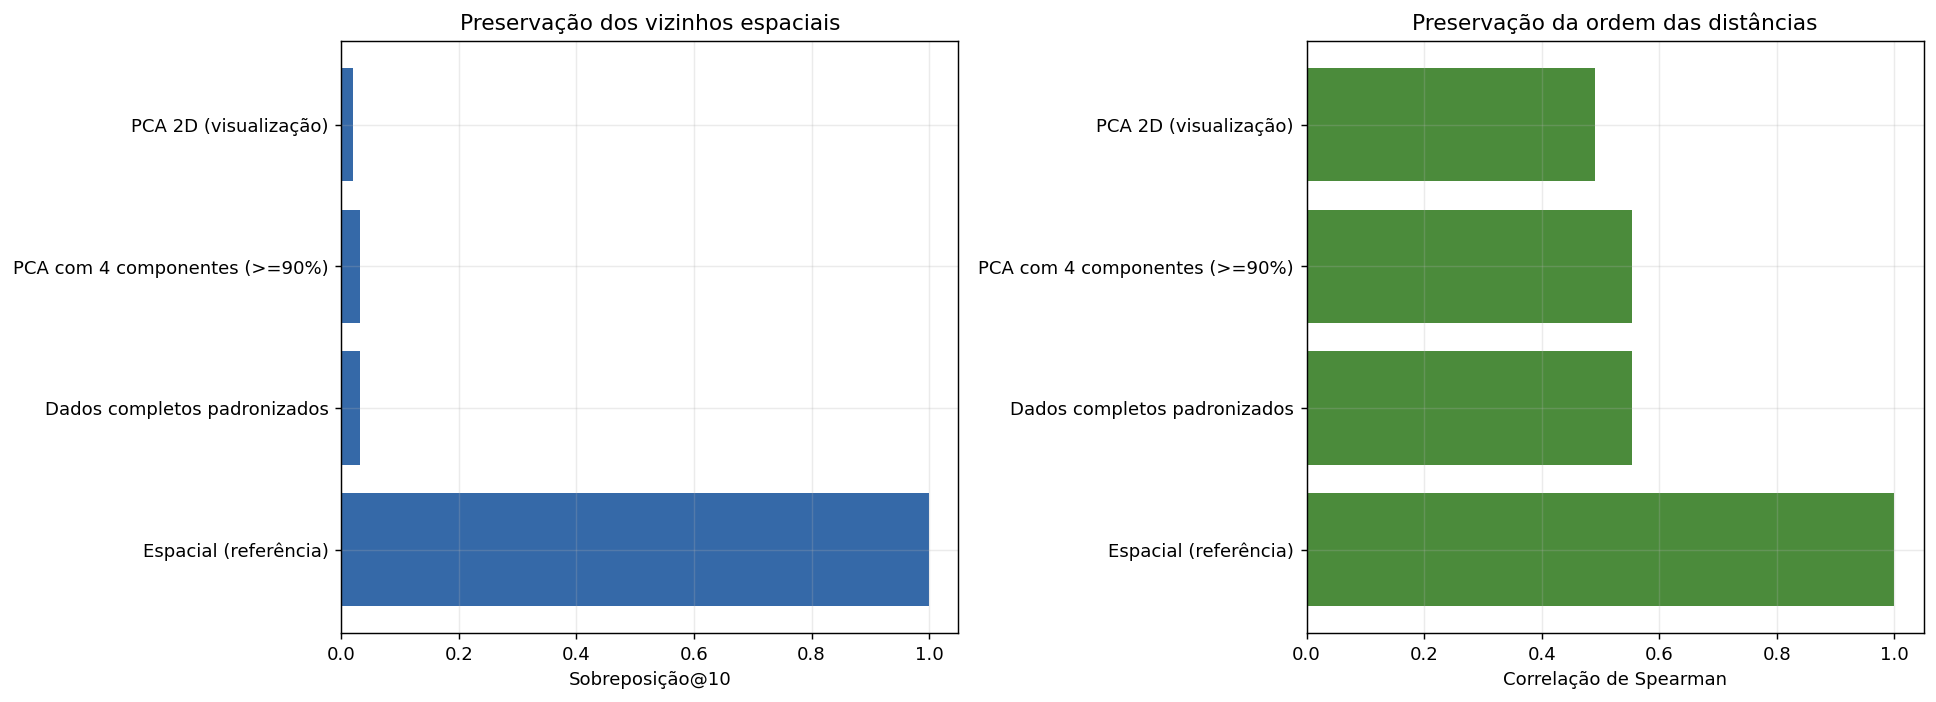

In [14]:
nomes = [linha[0] for linha in impacto_proximidade]
sobreposicoes = [linha[2] for linha in impacto_proximidade]
correlacoes_distancia = [linha[4] for linha in impacto_proximidade]

fig, eixos = plt.subplots(1, 2, figsize=(15, 5.5))
eixos[0].barh(nomes, sobreposicoes, color="#3569a8")
eixos[0].set_xlim(0, 1.05)
eixos[0].set_title("Preservação dos vizinhos espaciais")
eixos[0].set_xlabel("Sobreposição@10")

eixos[1].barh(nomes, correlacoes_distancia, color="#4b8b3b")
eixos[1].set_xlim(0, 1.05)
eixos[1].set_title("Preservação da ordem das distâncias")
eixos[1].set_xlabel("Correlação de Spearman")
fig.tight_layout()
plt.show()


## 9. Conclusões


In [15]:
pares_pearson = []
for i in range(len(COLUNAS_NUMERICAS)):
    for j in range(i + 1, len(COLUNAS_NUMERICAS)):
        pares_pearson.append((abs(pearson[i, j]), COLUNAS_NUMERICAS[i], COLUNAS_NUMERICAS[j], pearson[i, j]))
_, variavel_a, variavel_b, maior_pearson = max(pares_pearson)

completo = next(linha for linha in impacto_proximidade if linha[0] == "Dados completos padronizados")
pca_2d = next(linha for linha in impacto_proximidade if linha[0] == "PCA 2D (visualização)")

print("CONCLUSÕES DA ETAPA 2")
print("=" * 75)
print(f"1. Foram analisados {len(X)} registros tratados, sem valores ausentes ou duplicatas.")
print(
    f"2. A maior correlação linear absoluta ocorreu entre {variavel_a} e {variavel_b} "
    f"(Pearson = {maior_pearson:.3f})."
)
print("3. Nenhuma variável atingiu o limiar de redundância de |correlação| >= 0,80.")
print(
    f"4. O PCA precisa de {n_componentes_90} componentes para preservar ao menos 90% "
    "da variância; portanto, não oferece redução relevante sem perda."
)
print(
    f"5. Os dados completos preservam {completo[2] * 100:.1f}% dos 10 vizinhos espaciais, "
    "mostrando que incluir tempo altera bastante o conceito de proximidade."
)
print(
    f"6. O PCA 2D preserva {pca_2d[2] * 100:.1f}% dos vizinhos espaciais e deve ser "
    "utilizado principalmente para visualização."
)
print(
    "7. Para agrupamentos espaciais, recomenda-se usar Lat e Lon. Para análises "
    "espaçotemporais, Hour e Day devem ser incluídos com pesos definidos conforme o objetivo."
)


CONCLUSÕES DA ETAPA 2
1. Foram analisados 19220 registros tratados, sem valores ausentes ou duplicatas.
2. A maior correlação linear absoluta ocorreu entre Lat e Lon (Pearson = 0.147).
3. Nenhuma variável atingiu o limiar de redundância de |correlação| >= 0,80.
4. O PCA precisa de 4 componentes para preservar ao menos 90% da variância; portanto, não oferece redução relevante sem perda.
5. Os dados completos preservam 3.1% dos 10 vizinhos espaciais, mostrando que incluir tempo altera bastante o conceito de proximidade.
6. O PCA 2D preserva 2.0% dos vizinhos espaciais e deve ser utilizado principalmente para visualização.
7. Para agrupamentos espaciais, recomenda-se usar Lat e Lon. Para análises espaçotemporais, Hour e Day devem ser incluídos com pesos definidos conforme o objetivo.
